11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6919 - loss: 1.2620
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8563 - loss: 0.6350
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8836 - loss: 0.4956
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8923 - loss: 0.4290
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9023 - loss: 0.3895
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8987 - loss: 0.3933
Accuracy: 0.8986999988555908
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Prediction: 7
Actual Label: 7


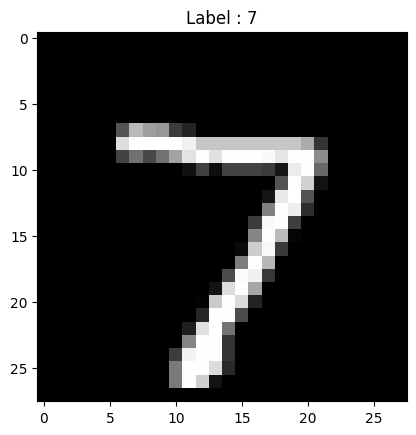

In [2]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Load MNIST dataset
mnist = tf.keras.datasets.mnist

# Split into train and test
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Normalize data
train_images = train_images / 255.0
test_images = test_images / 255.0

# Use only first 10000 examples
max_examples = 10000
train_images = train_images[:max_examples]
train_labels = train_labels[:max_examples]

# Flatten images (28x28 -> 784)
train_images = train_images.reshape(-1, 784)
test_images = test_images.reshape(-1, 784)

# Build model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='softmax', input_shape=(784,))
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
model.fit(train_images, train_labels, epochs=5, batch_size=100)

# Evaluate accuracy
loss, accuracy = model.evaluate(test_images, test_labels)

print("Accuracy:", accuracy)

# Predict first image
prediction = model.predict(test_images[0].reshape(1, 784))

predicted_label = np.argmax(prediction)

print("Prediction:", predicted_label)
print("Actual Label:", test_labels[0])

# Display image
plt.title(f'Label : {test_labels[0]}')
plt.imshow(test_images[0].reshape(28, 28), cmap='gray')
plt.show()